<a href="https://colab.research.google.com/github/Peace3B/student_dropout_summative_assignment/blob/main/student_dropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **STUDENT DROPOUT DATASET**

In [ ]:
!pip install tensorflow


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import RMSprop, Adam
from tensorflow.keras.regularizers import l2, l1
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving student dropout.csv to student dropout.csv


In [ ]:
df = pd.read_csv('/content/student dropout.csv')

In [ ]:
df

,School,Gender,Age,Address,Family_Size,Parental_Status,Mother_Education,Father_Education,Mother_Job,Father_Job,...,Free_Time,Going_Out,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Health_Status,Number_of_Absences,Grade_1,Grade_2,Final_Grade,Dropped_Out
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,4,0,11,11,False
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,2,9,11,11,False
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,6,12,13,12,False
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,0,14,14,14,False
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,0,11,13,13,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,...,4,2,1,2,5,4,10,11,10,False
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,3,4,1,1,1,4,15,15,16,False
646,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,5,6,11,12,9,True
647,MS,M,17,U,LE3,T,3,1,services,services,...,4,5,3,4,2,6,10,10,10,False


In [ ]:
# Select relevant columns for the analysis
columns_to_keep = [
    'Dropped_Out', 'Mother_Education', 'Father_Education', 'Final_Grade', 'Grade_1',
    'Grade_2', 'Number_of_Failures', 'School', 'Wants_Higher_Education', 'Study_Time',
    'Weekend_Alcohol_Consumption', 'Weekday_Alcohol_Consumption', 'Address',
    'Reason_for_Choosing_School'
]
df = df[columns_to_keep].copy() # Use .copy() to avoid SettingWithCopyWarning

# --- Data Preprocessing and Feature Engineering ---

# Handle missing values (Example: Impute with median for numerical, mode for categorical)
# Check for missing values first to decide on the best imputation strategy
print("Missing values before handling:")
print(df.isnull().sum())

# Example imputation:
# For numerical columns, impute with median
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in numerical_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

# For categorical columns, impute with mode
categorical_cols = df.select_dtypes(include='object').columns.tolist()
for col in categorical_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)

print("\nMissing values after handling:")
print(df.isnull().sum())


# Handle outliers (Example: using IQR for numerical features)
# Note: Outlier handling can be complex and depends on the data distribution.
# This is a basic example for numerical columns.
for col in numerical_cols:
    if col != 'Dropped_Out': # Exclude the target variable
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Cap outliers at the bounds
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)


# Feature Engineering (Example: Create a new feature)
# Combine alcohol consumption features
df['Total_Alcohol_Consumption'] = df['Weekend_Alcohol_Consumption'] + df['Weekday_Alcohol_Consumption']

# Convert boolean target variable to integer
df['Dropped_Out'] = df['Dropped_Out'].astype(int)


# Display the first few rows of the processed DataFrame
print("\nProcessed DataFrame head:")
display(df.head())

Missing values before handling:
Dropped_Out                    0
Mother_Education               0
Father_Education               0
Final_Grade                    0
Grade_1                        0
Grade_2                        0
Number_of_Failures             0
School                         0
Wants_Higher_Education         0
Study_Time                     0
Weekend_Alcohol_Consumption    0
Weekday_Alcohol_Consumption    0
Address                        0
Reason_for_Choosing_School     0
dtype: int64

Missing values after handling:
Dropped_Out                    0
Mother_Education               0
Father_Education               0
Final_Grade                    0
Grade_1                        0
Grade_2                        0
Number_of_Failures             0
School                         0
Wants_Higher_Education         0
Study_Time                     0
Weekend_Alcohol_Consumption    0
Weekday_Alcohol_Consumption    0
Address                        0
Reason_for_Choosing_School     0

,Dropped_Out,Mother_Education,Father_Education,Final_Grade,Grade_1,Grade_2,Number_of_Failures,School,Wants_Higher_Education,Study_Time,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Address,Reason_for_Choosing_School,Total_Alcohol_Consumption
0,0,4,4,11,5.5,11.0,0,GP,yes,2.0,1.0,1,U,course,2.0
1,0,1,1,11,9.0,11.0,0,GP,yes,2.0,1.0,1,U,course,2.0
2,0,1,1,12,12.0,13.0,0,GP,yes,2.0,2.0,3,U,other,5.0
3,0,4,2,14,14.0,14.0,0,GP,yes,3.0,1.0,1,U,home,2.0
4,0,3,3,13,11.0,13.0,0,GP,yes,2.0,1.0,2,U,home,3.0


In [ ]:
categories = df.select_dtypes(include=['object']).columns

df_new = pd.get_dummies(df, columns=categories, drop_first=True)
df_new.head()

,Dropped_Out,Mother_Education,Father_Education,Final_Grade,Grade_1,Grade_2,Number_of_Failures,Study_Time,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,School_MS,Wants_Higher_Education_yes,Address_U,Reason_for_Choosing_School_home,Reason_for_Choosing_School_other,Reason_for_Choosing_School_reputation
0,False,4,4,11,0,11,0,2,1,1,False,True,True,False,False,False
1,False,1,1,11,9,11,0,2,1,1,False,True,True,False,False,False
2,False,1,1,12,12,13,0,2,2,3,False,True,True,False,True,False
3,False,4,2,14,14,14,0,3,1,1,False,True,True,True,False,False
4,False,3,3,13,11,13,0,2,1,2,False,True,True,True,False,False


In [ ]:
import pickle
category_mapping = {}
for column in categories:
    unique_values = df[column].unique()
    for value in unique_values:
        one_hot_column_name = f"{column}_{value}"
        category_mapping[column + '_' + value] = one_hot_column_name

with open('category_mapping.pkl', 'wb') as file:
    pickle.dump(category_mapping, file)

In [ ]:
with open('category_mapping.pkl', 'rb') as file:
    category_mapping = pickle.load(file)

def map_input_row(input_row, category_mapping):
    """
    Maps a row of input features (including categorical features) to their
    corresponding one-hot encoded values.

    Args:
        input_row: A dictionary representing a row of input features.
        category_mapping: The dictionary containing the mapping.

    Returns:
        A pandas Series containing the one-hot encoded values,
        or None if no mapping is found for any feature.
    """
    encoded_values = pd.Series(0, index=category_mapping.values())

    for feature_name, feature_value in input_row.items():
        if feature_name in set([k.split('_')[0] for k in category_mapping]):  # If feature is categorical
            one_hot_column_name = category_mapping.get(feature_name + '_' + feature_value)

            if one_hot_column_name:
                encoded_values[one_hot_column_name] = 1
            else:
                print(f"Warning: No mapping found for {feature_name}: {feature_value}")
                # You might want to handle missing mappings differently here

    return encoded_values

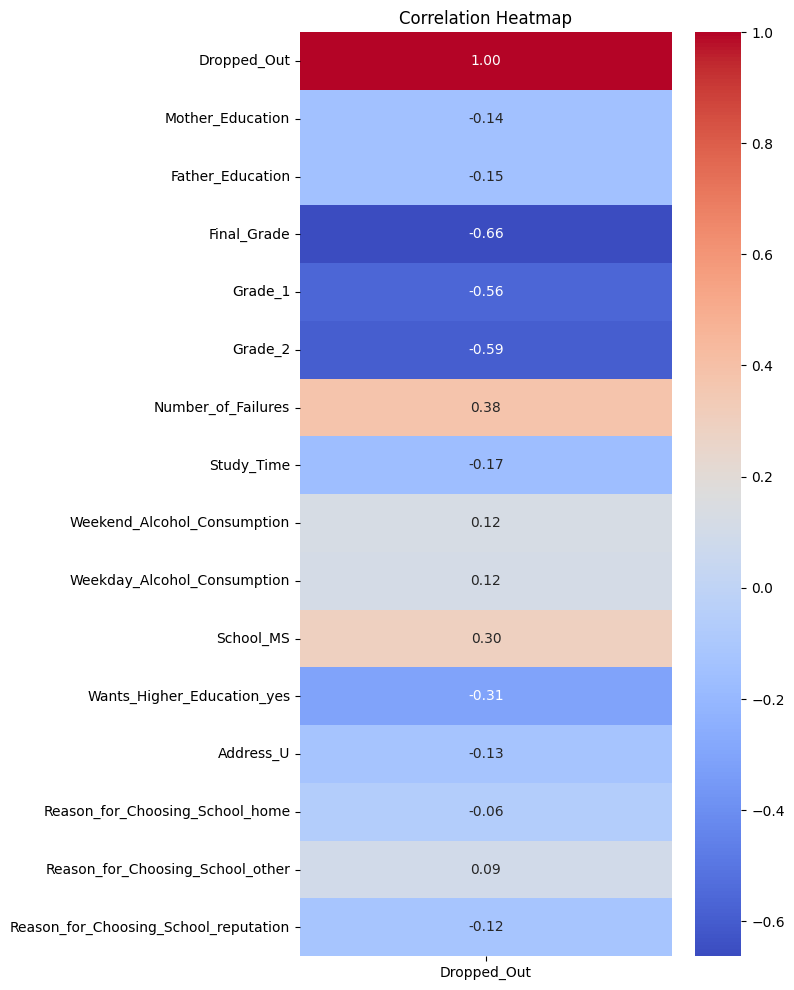

In [ ]:
correlation = df_new.corr()[['Dropped_Out']]
plt.figure(figsize=(6,12))
sns.heatmap(correlation, cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
x = df_new.drop(columns=['Dropped_Out'])
y = df_new['Dropped_Out']

In [ ]:
scaler = StandardScaler()
X_scaled =scaler.fit_transform(x)
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Testing set:", X_test.shape, y_test.shape)
print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training set: (454, 15) (454,)
Validation set: (97, 15) (97,)
Testing set: (98, 15) (98,)
Training samples: 454
Validation samples: 97
Test samples: 98


In [ ]:

def model():
    # Define the model
    model = Sequential()
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.006)))
    model.add(BatchNormalization())
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.006)))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))
    # model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    # Compile the model
    model.compile(optimizer=RMSprop(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def train_model(model, X_train, y_train, X_val, y_val):
    # Early stopping callback
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Train the model
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=400, verbose=2, callbacks=[early_stopping])
    return history
model = model()
history = train_model(model, X_train, y_train, X_val, y_val)

Epoch 1/400
15/15 - 3s - 182ms/step - accuracy: 0.6894 - loss: 1.2991 - val_accuracy: 0.8351 - val_loss: 1.2234
Epoch 2/400
15/15 - 0s - 11ms/step - accuracy: 0.7643 - loss: 1.1572 - val_accuracy: 0.8247 - val_loss: 1.1650
Epoch 3/400
15/15 - 0s - 11ms/step - accuracy: 0.8524 - loss: 1.0188 - val_accuracy: 0.8866 - val_loss: 1.1065
Epoch 4/400
15/15 - 0s - 10ms/step - accuracy: 0.8855 - loss: 0.9431 - val_accuracy: 0.8969 - val_loss: 1.0469
Epoch 5/400
15/15 - 0s - 9ms/step - accuracy: 0.8855 - loss: 0.9022 - val_accuracy: 0.9278 - val_loss: 0.9814
Epoch 6/400
15/15 - 0s - 10ms/step - accuracy: 0.9141 - loss: 0.8363 - val_accuracy: 0.9278 - val_loss: 0.9119
Epoch 7/400
15/15 - 0s - 9ms/step - accuracy: 0.9295 - loss: 0.7668 - val_accuracy: 0.9381 - val_loss: 0.8487
Epoch 8/400
15/15 - 0s - 10ms/step - accuracy: 0.9251 - loss: 0.7753 - val_accuracy: 0.9381 - val_loss: 0.7938
Epoch 9/400
15/15 - 0s - 9ms/step - accuracy: 0.9559 - loss: 0.6679 - val_accuracy: 0.9381 - val_loss: 0.7375
Epo

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Model Evaluation:
Accuracy: 0.9592
Precision: 0.8889
Recall: 0.7273
F1 Score: 0.8000


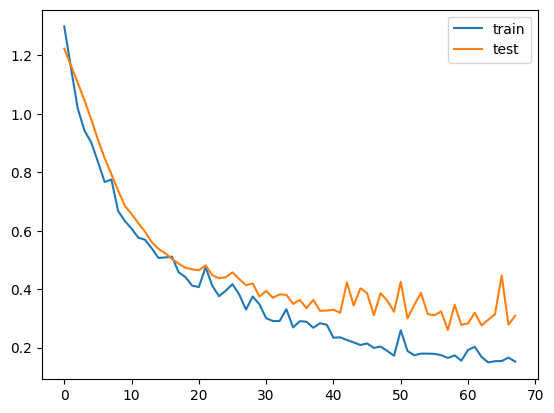

In [ ]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
y_pred = (model.predict(X_test) > 0.5).astype("int32")
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# plot training history
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

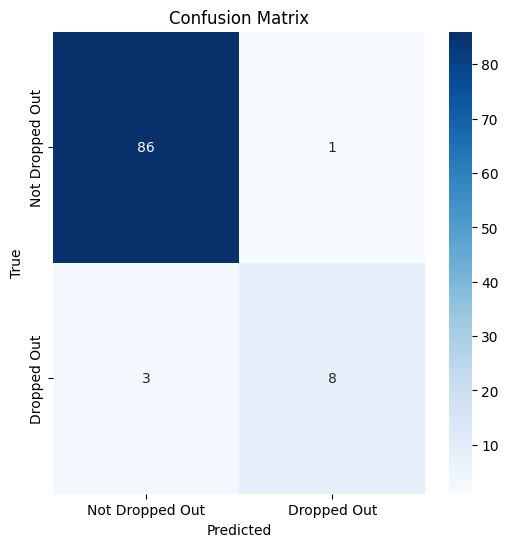

In [ ]:

cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix using Seaborn heatmap
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=['Not Dropped Out', 'Dropped Out'], yticklabels=['Not Dropped Out', 'Dropped Out'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
import pickle
with open('model.pkl', 'wb') as file:
    pickle.dump(model, file)

In [ ]:
model.save('model.keras')

In [ ]:
#list of 7 different machine learning models

models_to_consider = {
    "Logistic Regression": "A linear model that uses the logistic function to model the probability of a binary outcome. Simple, interpretable, and a good baseline.",
    "Support Vector Machine (SVM)": "A powerful model that finds an optimal hyperplane to separate classes, effective in high-dimensional spaces and with non-linear data using kernels.",
    "Decision Tree": "A tree-like structure where each internal node represents a feature, each branch represents a decision rule, and each leaf node represents the outcome. Interpretable and can capture non-linear relationships.",
    "Random Forest": "An ensemble method that builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting.",
    "Gradient Boosting (e.g., LightGBM, XGBoost)": "Another ensemble method that builds trees sequentially, where each new tree corrects the errors of the previous ones, often achieving high accuracy.",
    "K-Nearest Neighbors (KNN)": "A non-parametric algorithm that classifies a data point based on the majority class of its k nearest neighbors. Simple and intuitive.",
    "Naive Bayes": "A probabilistic classifier based on Bayes' theorem with the assumption of conditional independence between features. Fast and can perform well on high-dimensional data.",
    "Neural Network (Dense Layers)": "A network of interconnected nodes (neurons) organized in layers, capable of learning complex non-linear patterns in the data."
}

print("Selected Machine Learning Models for Binary Classification:")
for model, description in models_to_consider.items():
    print(f"- {model}: {description}")

Selected Machine Learning Models for Binary Classification:
- Logistic Regression: A linear model that uses the logistic function to model the probability of a binary outcome. Simple, interpretable, and a good baseline.
- Support Vector Machine (SVM): A powerful model that finds an optimal hyperplane to separate classes, effective in high-dimensional spaces and with non-linear data using kernels.
- Decision Tree: A tree-like structure where each internal node represents a feature, each branch represents a decision rule, and each leaf node represents the outcome. Interpretable and can capture non-linear relationships.
- Random Forest: An ensemble method that builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting.
- Gradient Boosting (e.g., LightGBM, XGBoost): Another ensemble method that builds trees sequentially, where each new tree corrects the errors of the previous ones, often achieving high accuracy.
- K-Nearest Neighbors (KNN): A n

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Initialize models with default parameters
models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(probability=True), # probability=True is needed for some future steps, but not strictly for baseline
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }
    print(f"{name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

print("\nBaseline Model Performance:")
for name, metrics in results.items():
    print(f"{name}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")

Training Logistic Regression...
Logistic Regression - Accuracy: 0.9796, Precision: 0.9091, Recall: 0.9091, F1 Score: 0.9091
Training SVM...
SVM - Accuracy: 0.9694, Precision: 0.9000, Recall: 0.8182, F1 Score: 0.8571
Training Decision Tree...
Decision Tree - Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1 Score: 1.0000
Training Random Forest...
Random Forest - Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1 Score: 1.0000
Training Gradient Boosting...
Gradient Boosting - Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1 Score: 1.0000
Training KNN...
KNN - Accuracy: 0.9286, Precision: 0.7000, Recall: 0.6364, F1 Score: 0.6667
Training Naive Bayes...
Naive Bayes - Accuracy: 0.8673, Precision: 0.4500, Recall: 0.8182, F1 Score: 0.5806

Baseline Model Performance:
Logistic Regression:
  Accuracy: 0.9796
  Precision: 0.9091
  Recall: 0.9091
  F1 Score: 0.9091
SVM:
  Accuracy: 0.9694
  Precision: 0.9000
  Recall: 0.8182
  F1 Score: 0.8571
Decision Tree:
  Accuracy: 1.0000
 

In [ ]:
# Feature Selection: Select features with absolute correlation above a certain threshold
correlation_threshold = 0.1 # Example threshold, can be adjusted
highly_correlated_features = correlation[abs(correlation['Dropped_Out']) > correlation_threshold].index.tolist()

# Exclude the target variable itself from the features list
if 'Dropped_Out' in highly_correlated_features:
    highly_correlated_features.remove('Dropped_Out')

print(f"Features with absolute correlation > {correlation_threshold}: {highly_correlated_features}")

# Create new feature sets
X_correlated = df_new[highly_correlated_features]
y_correlated = df_new['Dropped_Out']

# Scale the new feature set
scaler_correlated = StandardScaler()
X_correlated_scaled = scaler_correlated.fit_transform(X_correlated)

# Split the new data set
X_train_correlated, X_temp_correlated, y_train_correlated, y_temp_correlated = train_test_split(
    X_correlated_scaled, y_correlated, test_size=0.3, random_state=42
)
X_val_correlated, X_test_correlated, y_val_correlated, y_test_correlated = train_test_split(
    X_temp_correlated, y_temp_correlated, test_size=0.5, random_state=42
)

print("\nShape of new data splits (correlated features):")
print("Training set:", X_train_correlated.shape, y_train_correlated.shape)
print("Validation set:", X_val_correlated.shape, y_val_correlated.shape)
print("Testing set:", X_test_correlated.shape, y_test_correlated.shape)


# Now, retrain and evaluate the models using this new feature set (X_correlated_scaled, y_correlated)
# We will use the best parameters found during the previous hyperparameter tuning step.

tuned_results_correlated_features = {}

for name, model in models.items():
    print(f"\n retraining and evaluating {name} with correlated features...")

    if name == "Naive Bayes":
        print("Skipping Naive Bayes with correlated features (due to feature mismatch).")
        # We will not re-evaluate Naive Bayes with correlated features in this loop
        continue


    # Get the best parameters from the previous tuning step
    best_params = tuned_results[name].get("Best Parameters")

    if best_params:
        # Initialize the model with the best parameters
        best_model = model.__class__(**best_params)
    else:
        # If no best parameters were found (shouldn't happen with the current flow, but as a fallback)
        best_model = model

    # Train the model on the correlated feature set
    best_model.fit(X_train_correlated, y_train_correlated)

    # Make predictions on the test set
    y_pred_correlated = best_model.predict(X_test_correlated)

    # Evaluate the model
    accuracy_correlated = accuracy_score(y_test_correlated, y_pred_correlated)
    precision_correlated = precision_score(y_test_correlated, y_pred_correlated)
    recall_correlated = recall_score(y_test_correlated, y_pred_correlated)
    f1_correlated = f1_score(y_test_correlated, y_pred_correlated)

    # Store the results
    tuned_results_correlated_features[name] = {
        "Best Parameters (from previous tuning)": best_params,
        "Accuracy (Correlated Features)": accuracy_correlated,
        "Precision (Correlated Features)": precision_correlated,
        "Recall (Correlated Features)": recall_correlated,
        "F1 Score (Correlated Features)": f1_correlated
    }

    print(f"{name} - Tuned Accuracy (Correlated Features): {accuracy_correlated:.4f}, "
          f"Precision (Correlated Features): {precision_correlated:.4f}, "
          f"Recall (Correlated Features): {recall_correlated:.4f}, "
          f"F1 Score (Correlated Features): {f1_correlated:.4f}")

# Add Naive Bayes results for correlated features separately if needed, or note the exclusion.
# For now, we exclude it from this comparison with correlated features due to the mismatch.

Features with absolute correlation > 0.1: ['Mother_Education', 'Father_Education', 'Final_Grade', 'Grade_1', 'Grade_2', 'Number_of_Failures', 'Study_Time', 'Weekend_Alcohol_Consumption', 'Weekday_Alcohol_Consumption', 'School_MS', 'Wants_Higher_Education_yes', 'Address_U', 'Reason_for_Choosing_School_reputation']

Shape of new data splits (correlated features):
Training set: (454, 13) (454,)
Validation set: (97, 13) (97,)
Testing set: (98, 13) (98,)

 retraining and evaluating Logistic Regression with correlated features...
Logistic Regression - Tuned Accuracy (Correlated Features): 1.0000, Precision (Correlated Features): 1.0000, Recall (Correlated Features): 1.0000, F1 Score (Correlated Features): 1.0000

 retraining and evaluating SVM with correlated features...
SVM - Tuned Accuracy (Correlated Features): 1.0000, Precision (Correlated Features): 1.0000, Recall (Correlated Features): 1.0000, F1 Score (Correlated Features): 1.0000

 retraining and evaluating Decision Tree with correla

In [ ]:
# Combine and display the results for comparison
comparison_results = {}

for name in tuned_results.keys():
    # Check if the model was evaluated with correlated features
    if name in tuned_results_correlated_features:
        comparison_results[name] = {
            "All Features - Accuracy": tuned_results[name]["Accuracy"],
            "All Features - Precision": tuned_results[name]["Precision"],
            "All Features - Recall": tuned_results[name]["Recall"],
            "All Features - F1 Score": tuned_results[name]["F1 Score"],
            "Correlated Features - Accuracy": tuned_results_correlated_features[name]["Accuracy (Correlated Features)"],
            "Correlated Features - Precision": tuned_results_correlated_features[name]["Precision (Correlated Features)"],
            "Correlated Features - Recall": tuned_results_correlated_features[name]["Recall (Correlated Features)"],
            "Correlated Features - F1 Score": tuned_results_correlated_features[name]["F1 Score (Correlated Features)"]
        }
    else:
        # If the model was not evaluated with correlated features, include only the results from all features
        comparison_results[name] = {
            "All Features - Accuracy": tuned_results[name]["Accuracy"],
            "All Features - Precision": tuned_results[name]["Precision"],
            "All Features - Recall": tuned_results[name]["Recall"],
            "All Features - F1 Score": tuned_results[name]["F1 Score"],
            "Correlated Features - Accuracy": "N/A",
            "Correlated Features - Precision": "N/A",
            "Correlated Features - Recall": "N/A",
            "Correlated Features - F1 Score": "N/A"
        }


comparison_df = pd.DataFrame(comparison_results).T
print("\nModel Performance Comparison (Tuned Models):")
display(comparison_df)


Model Performance Comparison (Tuned Models):


,All Features - Accuracy,All Features - Precision,All Features - Recall,All Features - F1 Score,Correlated Features - Accuracy,Correlated Features - Precision,Correlated Features - Recall,Correlated Features - F1 Score
Logistic Regression,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
SVM,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Decision Tree,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Random Forest,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Gradient Boosting,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
KNN,0.928571,0.7,0.636364,0.666667,0.938776,0.777778,0.636364,0.7
Naive Bayes,0.867347,0.45,0.818182,0.580645,N/A,N/A,N/A,N/A
